# EDA - Caso B

**Objetivo**

Implementar un algoritmo para identificar los Top 5 "Combos" (conjuntos de productos) con
mayor potencial de venta (proponer el precio de cada combo) para diferentes clusters de
tiendas, cuantificando el "lift" esperado.

**Presentado por:** Natalia Andrea Sandoval Riveros

1. Cargue de librerias

In [18]:
import os # Manipulación de Directorios y Archivos
import pandas as pd # Permite leer y escribir fácilmente ficheros en formato CSV, Excel y bases de datos SQL
import numpy as np # Computación científica y análisis de datos

import warnings
warnings.filterwarnings('ignore')

2. Importar archivos

In [19]:
# Carga de archivos
catalogo = pd.read_csv(r'C:\Users\nata_\Documents\MLOps\Introduction_to_MLOps\proyecto_2\Combos_Tostao\data\catalogo_productos.csv') # Carga la tabla maestra de transacciones.
detalle = pd.read_csv(r'C:\Users\nata_\Documents\MLOps\Introduction_to_MLOps\proyecto_2\Combos_Tostao\data\detalle_tickets.csv') # Carga el desglose de productos por ticket.
tickets = pd.read_csv(r'C:\Users\nata_\Documents\MLOps\Introduction_to_MLOps\proyecto_2\Combos_Tostao\data\tickets.csv') # Carga la información descriptiva de productos.

In [20]:
# De la tabla 'detalle', nos interesan todas las columnas para el cálculo de ventas
df_detalle_reducido = detalle[['id_ticket', 'id_producto', 'cantidad', 'precio_unitario']] # Selecciona las columnas base de la venta.

# De la tabla 'catalogo', traemos el nombre y categorías para dar contexto al producto
df_catalogo_reducido = catalogo[['id_producto', 'nombre', 'categoria', 'subcategoria']] # Selecciona atributos descriptivos del producto.

# De la tabla 'tickets', traemos la ubicación, tiempo y cliente
df_tickets_reducido = tickets[['id_ticket', 'fecha', 'id_tienda', 'id_cliente']] # Selecciona datos de contexto de la transacción.

In [21]:
# Paso A: Unimos el detalle con el catálogo usando 'id_producto' como llave
df_temp = pd.merge(df_detalle_reducido, df_catalogo_reducido, on='id_producto', how='left') # Une descripción de productos a cada línea de venta.

# Paso B: Unimos el resultado con la tabla de tickets usando 'id_ticket'
df_final = pd.merge(df_temp, df_tickets_reducido, on='id_ticket', how='left') # Añade tienda, fecha y cliente a cada ítem vendido.

In [22]:
# Convertimos la fecha para que Python la entienda como tiempo real
df_final['fecha'] = pd.to_datetime(df_final['fecha']) # Permite análisis por días o meses.

# Creamos la columna de Venta Total por línea
df_final['venta_total'] = df_final['cantidad'] * df_final['precio_unitario'] # Multiplica cantidad por precio para ver el ingreso real.
print("¡Integración completada!") # Mensaje de confirmación.
df_final.info() # Muestra un resumen de las columnas y asegura que no haya nulos críticos.

¡Integración completada!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18376 entries, 0 to 18375
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_ticket        18376 non-null  object        
 1   id_producto      18376 non-null  object        
 2   cantidad         18376 non-null  int64         
 3   precio_unitario  18376 non-null  int64         
 4   nombre           18376 non-null  object        
 5   categoria        18376 non-null  object        
 6   subcategoria     18376 non-null  object        
 7   fecha            18376 non-null  datetime64[ns]
 8   id_tienda        18376 non-null  object        
 9   id_cliente       18376 non-null  object        
 10  venta_total      18376 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 1.5+ MB


In [23]:
df_final.head()

,id_ticket,id_producto,cantidad,precio_unitario,nombre,categoria,subcategoria,fecha,id_tienda,id_cliente,venta_total
0,TICKET_000001,PROD_030,1,4500,Torta de Zanahoria,Alimentos,Panadería Dulce,2024-08-29,TOSTAO_15,CUST_01364,4500
1,TICKET_000002,PROD_006,1,2500,Aromática,Bebidas,Calientes,2024-02-04,TOSTAO_18,CUST_01956,2500
2,TICKET_000003,PROD_033,1,1500,Chocolatina,Alimentos,Panadería Dulce,2024-02-23,TOSTAO_18,CUST_01501,1500
3,TICKET_000003,PROD_021,1,3500,Pastel de Pollo,Alimentos,Panadería Sal,2024-02-23,TOSTAO_18,CUST_01501,3500
4,TICKET_000004,PROD_019,1,3200,Empanada de Carne,Alimentos,Panadería Sal,2024-10-30,TOSTAO_08,CUST_01276,3200


In [24]:
 #Identificación de Huecos (NaN)

# Información que falta por columna
nulos = df_final.isnull().sum()
porcentaje_nulos = (nulos / len(df_final)) * 100

# Creamos una tablita para verlo claro
resumen_nulos = pd.DataFrame({
    'Faltantes': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Faltantes', ascending=False)

print("\nResumen de valores que nos faltan:")
print(resumen_nulos[resumen_nulos['Faltantes'] > 0])


Resumen de valores que nos faltan:
Empty DataFrame
Columns: [Faltantes, Porcentaje (%)]
Index: []


No hay valores faltantes

In [25]:
car_vars = [col for col in df_final.columns if df_final[col].dtype=='O'] #Traer las variables tipo Object
car_vars

['id_ticket',
 'id_producto',
 'nombre',
 'categoria',
 'subcategoria',
 'id_tienda',
 'id_cliente']

In [26]:
for col in car_vars:
    print(f'Nombre columna: {col}')
    print(f'Porcentaje de nulos: {df_final[col].isnull().sum()/len(df_final[col])*100}')
    print(df_final[col].value_counts(normalize=True))
    print('-' * 40)  # Muestra el resultado de A

Nombre columna: id_ticket
Porcentaje de nulos: 0.0
id_ticket
TICKET_002337    0.000218
TICKET_009948    0.000218
TICKET_002262    0.000218
TICKET_000024    0.000218
TICKET_009957    0.000218
                   ...   
TICKET_000023    0.000054
TICKET_000025    0.000054
TICKET_000026    0.000054
TICKET_000007    0.000054
TICKET_000009    0.000054
Name: proportion, Length: 10000, dtype: float64
----------------------------------------
Nombre columna: id_producto
Porcentaje de nulos: 0.0
id_producto
PROD_001    0.077220
PROD_012    0.074826
PROD_003    0.067860
PROD_002    0.051045
PROD_021    0.048759
PROD_010    0.048106
PROD_031    0.046202
PROD_019    0.044950
PROD_006    0.042936
PROD_015    0.037603
PROD_009    0.037222
PROD_017    0.036624
PROD_023    0.035100
PROD_016    0.034610
PROD_028    0.031291
PROD_024    0.029441
PROD_034    0.022366
PROD_035    0.020788
PROD_026    0.019754
PROD_013    0.019482
PROD_008    0.019373
PROD_029    0.016924
PROD_018    0.016598
PROD_004    0.01

El Tinto (7.7%) y la Gaseosa 400ml (7.4%) son los productos con mayor frecuencia.

La tienda está perfectamente balanceada entre Alimentos (50.9%) y Bebidas (49.0%). Esto es ideal para estrategias de venta cruzada equilibrada.

La Panadería Sal (31.8%) y las Bebidas Calientes (29.3%) dominan el surtido.

La distribución de registros por id_tienda es sumamente equitativa (todas rondan el 4.6% - 5.3%).

El cliente más frecuente solo representa el 0.15% de las transacciones, y son en total 2,455 clientes únicos.

3. Analísis Estadístico

In [27]:
# resumen estadístico
df_final.describe().T

,count,mean,min,25%,50%,75%,max,std
cantidad,18376.0,1.028189,1.0,1.0,1.0,1.0,3.0,0.167478
precio_unitario,18376.0,3472.654549,1500.0,2800.0,3200.0,3500.0,7500.0,1070.446761
fecha,18376,2024-06-29 13:13:53.783195392,2024-01-01 00:00:00,2024-03-29 00:00:00,2024-06-30 00:00:00,2024-09-30 00:00:00,2024-12-30 00:00:00,NaN
venta_total,18376.0,3556.649978,1500.0,2800.0,3500.0,4500.0,15000.0,1170.25138


Cantidad:

Media de 1.02: Nos indica que, por línea de ticket, casi nadie compra más de una unidad del mismo producto.

Percentil 75% es 1.0: Incluso en el 75% de los casos, la cantidad es 1 y la cantidad máxima es apenas 3.

Esto quiere decir que la gente compra de forma muy atomizada (unidades individuales). Esto refuerza la idea de que para subir el ticket promedio, no debemos intentar que compren más de lo mismo, sino que compren algo adicional (venta cruzada).

Precio Unitario:

Rango de Precios: Los productos van desde $1.500 hasta $7.500.

Ticket Promedio por ítem: El promedio por producto es de aproximadamente $3.472.

Desviación Estándar ($1.070): Los precios están relativamente cerca del promedio; no hay productos "extremadamente caros" que distorsionen la escala, lo que facilita crear combos balanceados.

Fecha:

Periodo: Los datos cubren exactamente un año completo, del 1 de enero de 2024 al 30 de diciembre de 2024.

Validación: Tenemos datos de todas las temporadas (escolar, mitad de año, fin de año), lo que da mucha robustez a los patrones que encontremos. No es una muestra sesgada de un solo mes.

Venta Total:

Máximo de $15.000: Aunque el precio máximo es $7.500, hay una venta total de línea de $15.000. Esto ocurre cuando alguien compró 2 unidades del producto más caro ($7.500 \times 2 = 15.000$).

4. Análisis Univariado

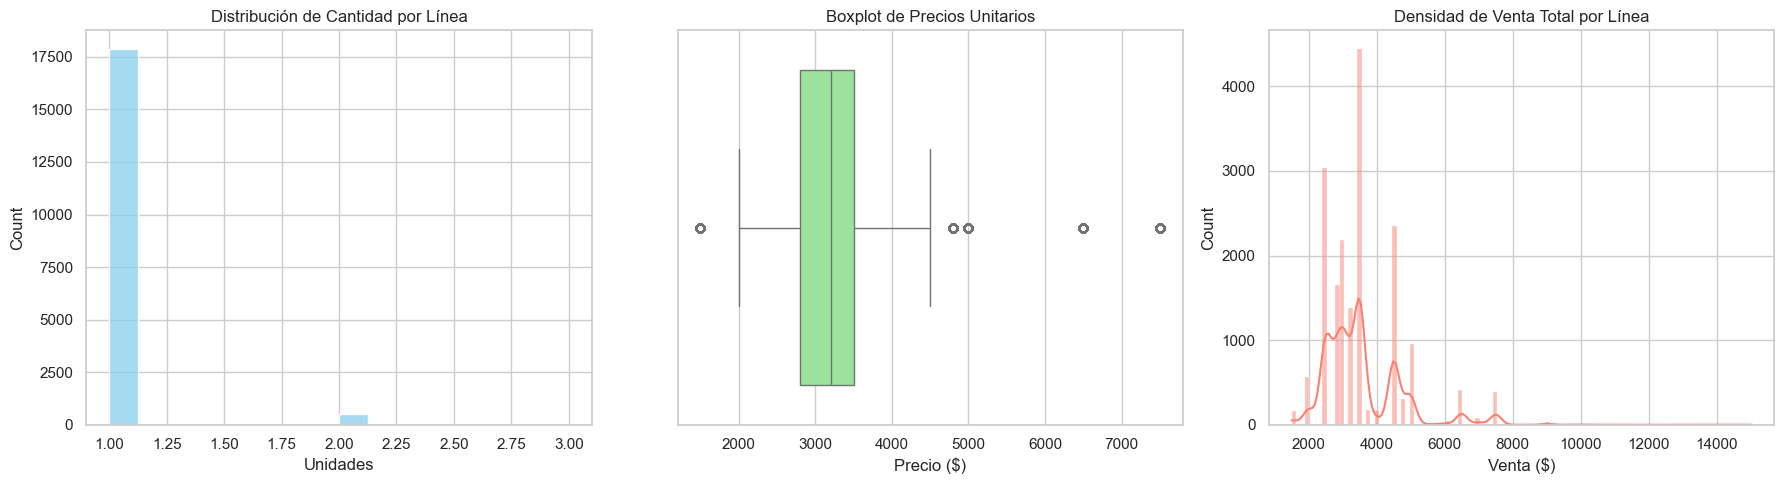

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración estética para el notebook
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de Cantidades
sns.histplot(df_final['cantidad'], kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Cantidad por Línea')
axes[0].set_xlabel('Unidades')

# 2. Distribución de Precios Unitarios
sns.boxplot(x=df_final['precio_unitario'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot de Precios Unitarios')
axes[1].set_xlabel('Precio ($)')

# 3. Distribución de Ventas Totales por Línea
sns.histplot(df_final['venta_total'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Densidad de Venta Total por Línea')
axes[2].set_xlabel('Venta ($)')

plt.tight_layout()
plt.show()

1. Distribución de Cantidad por Línea (Histograma Azul)
Existe una dominancia absoluta de la compra de una única unidad por producto (valor = 1.0). La frecuencia de 2 o 3 unidades es marginal.

La varianza de esta variable es mínima. Esto confirma que el esfuerzo de marketing no debe centrarse en "lleva más del mismo producto", sino en diversificar la canasta con productos complementarios.

2. Estructura de Precios (Boxplot Verde)
La caja (que contiene el 50% de los datos) está perfectamente centrada entre los $2,800 y $3,500.

Detección de Outliers: Se observan puntos aislados (puntos negros) por encima de los $5,000 y hasta los $7,500.

Estos valores extremos no son errores, sino productos de categorías "Premium". Para la creación de combos, estos productos pueden servir como elementos aspiracionales o "anclas" de valor.

3. Densidad de Venta Total por Línea (Gráfica de Densidad Roja)
La distribución es multimodal (tiene varios picos). Hay picos muy claros cerca de los $2,500, $3,500 y $4,500.

Estos picos representan los "puntos de precio" más comunes de la tienda. Los combos propuestos deberían apuntar a crear un nuevo pico de densidad hacia la derecha (ej. en el rango de $6,000 - $8,000) mediante la agrupación de dos productos de alta rotación.

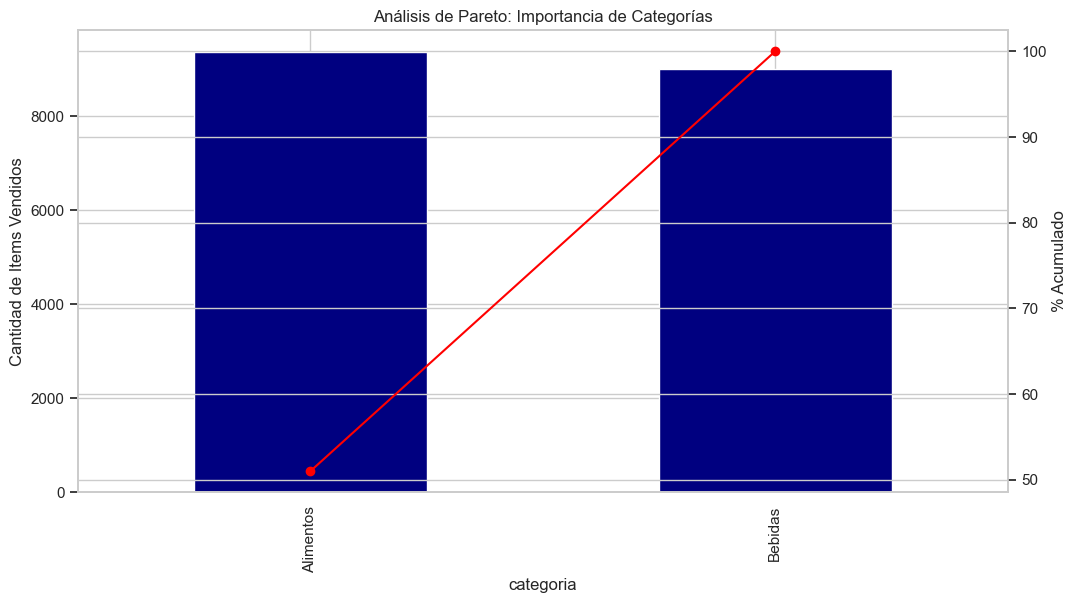

In [29]:
# Gráfica de Pareto para Categorías
cat_counts = df_final['categoria'].value_counts()
cat_perc = cat_counts.cumsum() / cat_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))
cat_counts.plot(kind='bar', ax=ax1, color='navy', label='Frecuencia')
ax2 = ax1.twinx()
ax2.plot(cat_perc.values, color='red', marker='o', label='Pareto %')

ax1.set_title('Análisis de Pareto: Importancia de Categorías')
ax1.set_ylabel('Cantidad de Items Vendidos')
ax2.set_ylabel('% Acumulado')
plt.show()

Efectivamente vemos un balanceo entre las dos clases, alimentos y bebidas.

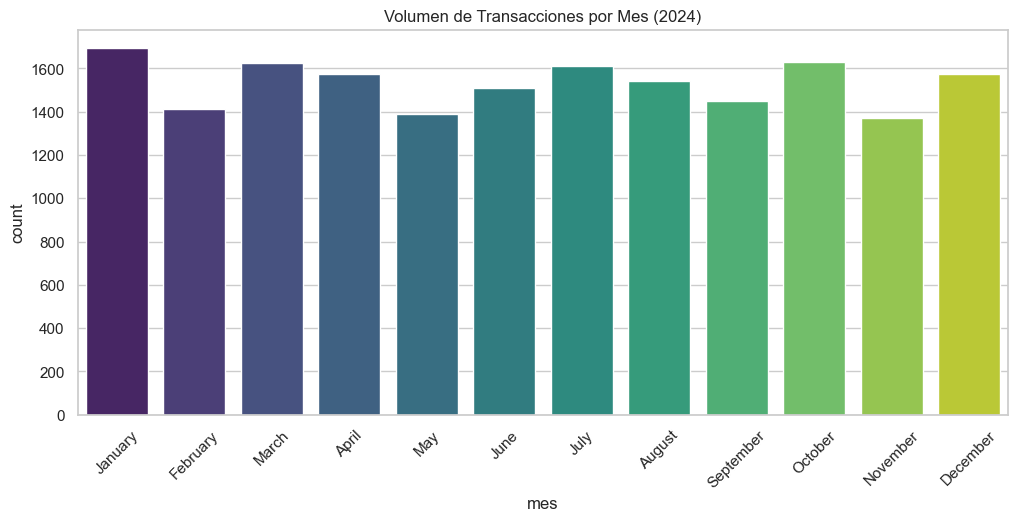

In [30]:
# Ventas por Mes
df_final['mes'] = df_final['fecha'].dt.month_name()
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 5))
sns.countplot(x='mes', data=df_final, order=orden_meses, palette='viridis')
plt.xticks(rotation=45)
plt.title('Volumen de Transacciones por Mes (2024)')
plt.show()

El volumen de ventas se mantiene bastante estable, oscilando mayormente entre las 1,400 y 1,700 transacciones mensuales.

El año inicia con un pico fuerte en enero (el mes con mayor actividad), seguido de una ligera disminución en febrero. Otros picos importantes se observan en marzo, julio y octubre. Noviembre se identifica como el mes con menor volumen de transacciones.

In [31]:
import sys
!{sys.executable} -m pip install wordcloud

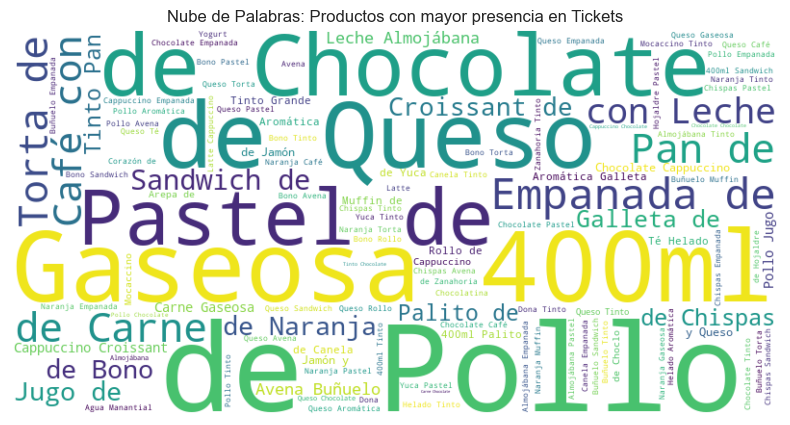

In [32]:
from wordcloud import WordCloud

text = " ".join(item for item in df_final['nombre'])
wordcloud = WordCloud(background_color="white", width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Nube de Palabras: Productos con mayor presencia en Tickets')
plt.show()

Términos como "Gaseosa 400ml", "Pollo", "Queso", "Torta de Chocolate" y "Pastel de de" (que se refiere a los pasteles de carne o pollo) dominan visualmente la gráfica.

5. Análisis Bivariado

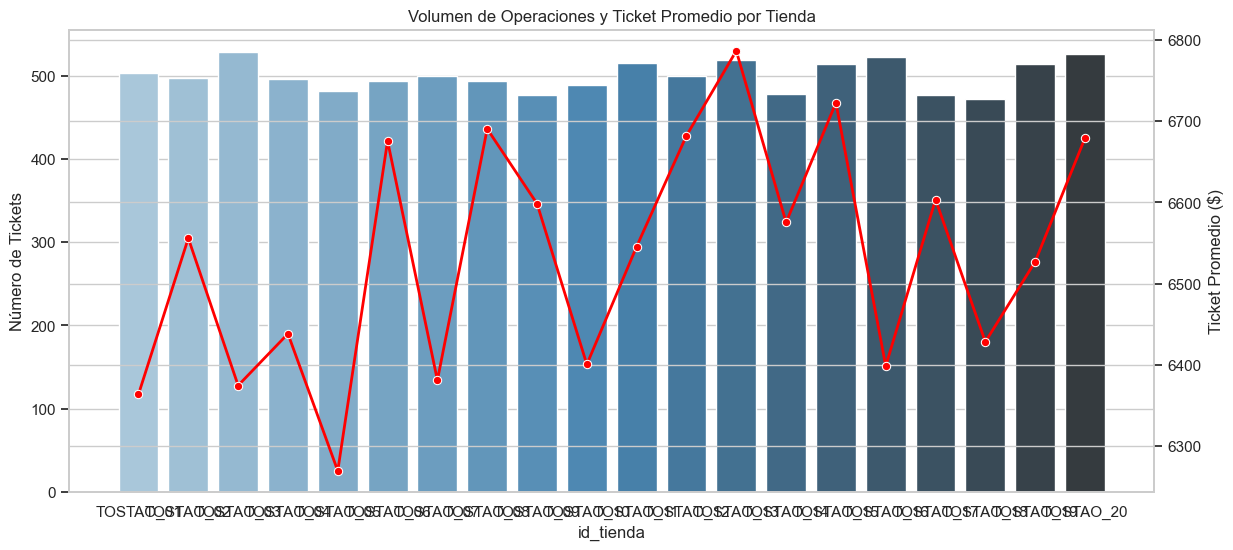

In [33]:
# 1. Agrupamos por tienda para ver volumen de transacciones y venta promedio
stats_tiendas = df_final.groupby('id_tienda').agg({
    'id_ticket': 'nunique',      # Cantidad de tickets únicos
    'venta_total': 'sum',        # Venta total en dinero
    'id_producto': 'count'       # Total de productos vendidos
}).reset_index()

# Calculamos el Ticket Promedio (AOV) por tienda
stats_tiendas['AOV'] = stats_tiendas['venta_total'] / stats_tiendas['id_ticket']

# Visualización
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras para el volumen de tickets
sns.barplot(x='id_tienda', y='id_ticket', data=stats_tiendas, ax=ax1, palette='Blues_d')
ax1.set_ylabel('Número de Tickets')
ax1.set_title('Volumen de Operaciones y Ticket Promedio por Tienda')

# Línea para el Ticket Promedio (AOV)
ax2 = ax1.twinx()
sns.lineplot(x=range(len(stats_tiendas)), y=stats_tiendas['AOV'], ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Ticket Promedio ($)')

plt.show()

Esta gráfica demuestra que un combo único para todas las tiendas sería ineficiente. Al existir una diferencia de casi $550 en el gasto promedio entre la tienda más alta y la más baja, la estrategia de precios debe ser segmentada por cluster para no quedar por encima del presupuesto del cliente en unas, ni perder margen en otras.

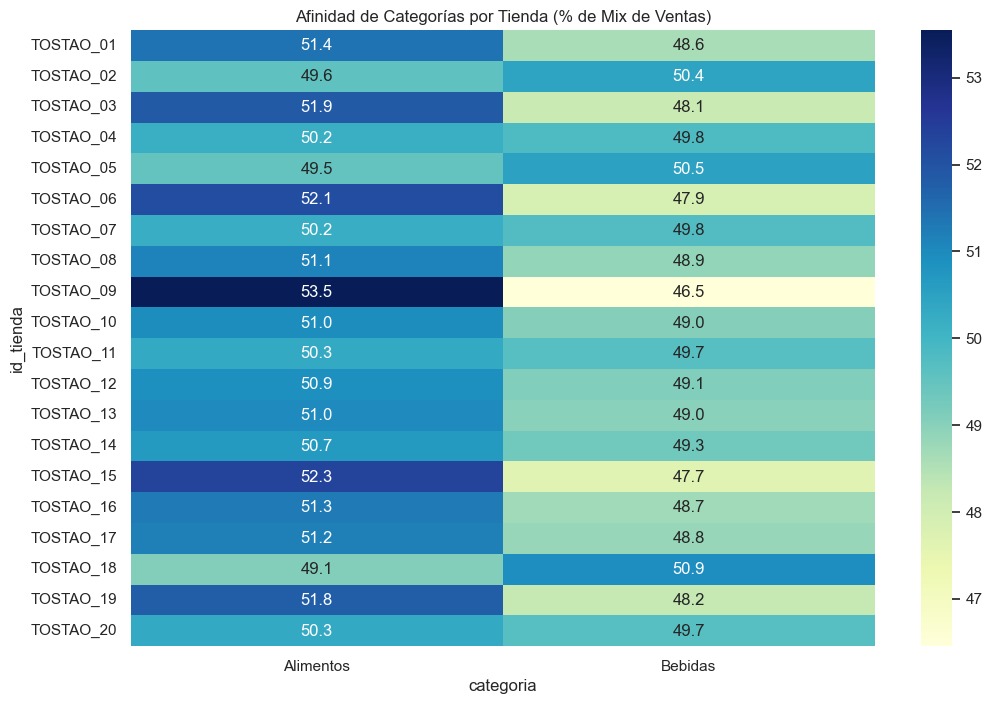

In [34]:
# Creamos una tabla cruzada de Tienda vs Categoría
tienda_cat = pd.crosstab(df_final['id_tienda'], df_final['categoria'], normalize='index') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(tienda_cat, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Afinidad de Categorías por Tienda (% de Mix de Ventas)')
plt.show()

El equilibrio entre Alimentos y Bebidas es bueno en todas las tiendas, pero hay algunas diferencias. La TOSTAO_09 es tu tienda más "comidista" (53.5% Alimentos), mientras que la TOSTAO_18 es la que más tira hacia las bebidas (50.9%).

Esto justifica que, aunque los combos sean similares, la comunicación en tienda debería priorizar el producto fuerte de cada ubicación.

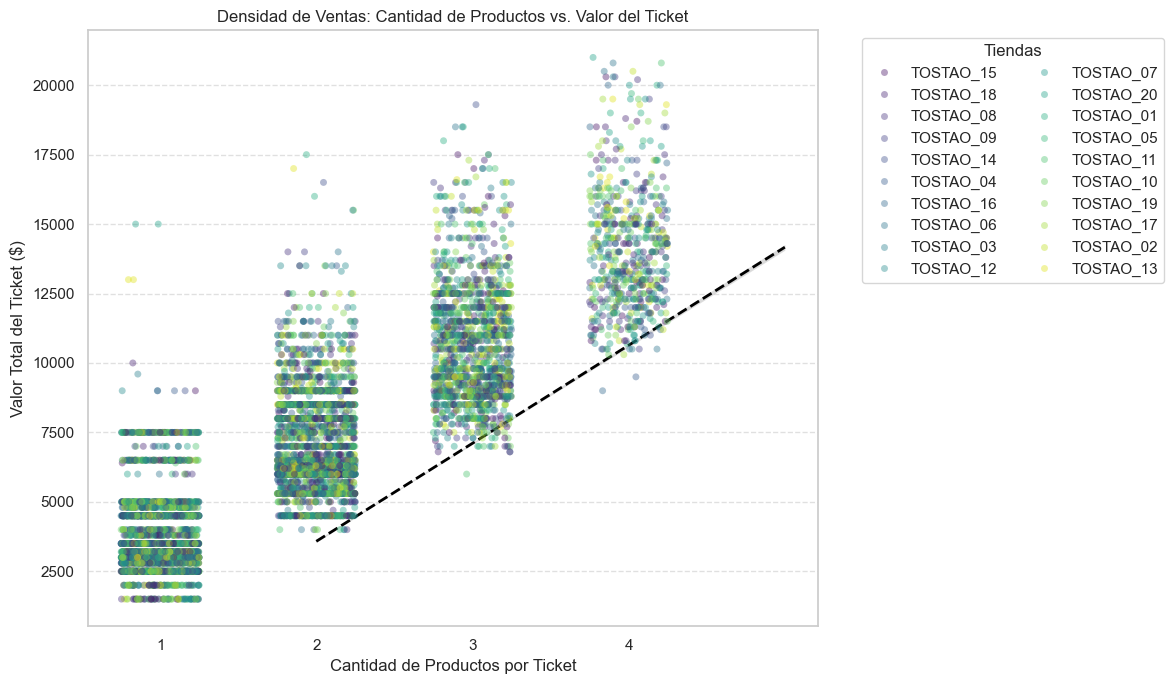

In [38]:
plt.figure(figsize=(12, 7))

# Agrupamos por ticket para obtener la venta total y el número de productos por ticket
ticket_stats = df_final.groupby(['id_ticket', 'id_tienda']).agg(
    venta_total=('venta_total', 'sum'),
    id_producto=('id_producto', 'count')
).reset_index()

# Usamos stripplot para el 'jitter' automático y jitter=0.2 para dispersión controlada
sns.stripplot(data=ticket_stats, x='id_producto', y='venta_total',
              hue='id_tienda', jitter=0.25, alpha=0.4, palette='viridis')

# Añadimos una línea de regresión para ver el crecimiento del ticket promedio
sns.regplot(data=ticket_stats, x='id_producto', y='venta_total',
            scatter=False, color='black', line_kws={"ls":"--", "lw":2})

# Arreglamos la leyenda para que no estorbe
plt.legend(title='Tiendas', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

plt.title('Densidad de Ventas: Cantidad de Productos vs. Valor del Ticket')
plt.xlabel('Cantidad de Productos por Ticket')
plt.ylabel('Valor Total del Ticket ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Se observa que la mayoria de los clientes compra 3 o 4 productos por ticket. La línea de tendencia negra muestra una correlación positiva clara: a más productos, más venta, pero los puntos dispersos arriba de la línea son tus ventas de alto margen.

Esto indica que el cliente ya tiene la cultura de comprar varios ítems. El reto no es que compren "más unidades", sino que esas unidades sumen más valor (up-selling).

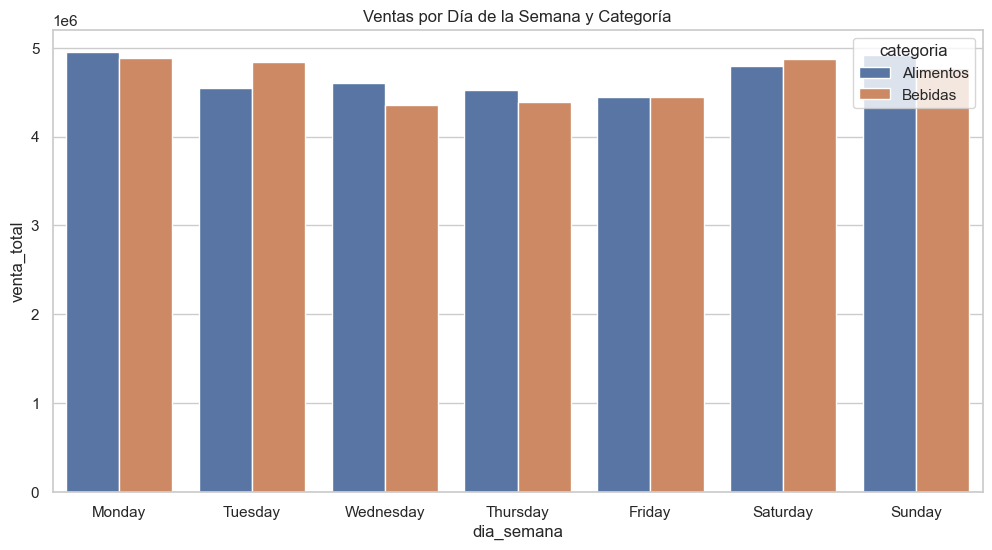

In [39]:
# Extraemos el nombre del día
df_final['dia_semana'] = df_final['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Agrupamos y graficamos
ventas_dia = df_final.groupby(['dia_semana', 'categoria'])['venta_total'].sum().reindex(orden_dias, level=0).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=ventas_dia, x='dia_semana', y='venta_total', hue='categoria')
plt.title('Ventas por Día de la Semana y Categoría')
plt.show()

Los lunes son el pico máximo para "Alimentos", mientras que los sábados las "Bebidas" toman la delantera. Los viernes parecen ser el día de menor actividad relativa.
Esto es oro para el despliegue. Puedes sugerir "Combos de inicio de semana" enfocados en panadería/alimentos y "Combos de fin de semana" más orientados a bebidas/refrigerios.

**Conclusiones**

Identificación de Productos "Ruido":

Se identificó una alta concentración de ventas en productos como "Tinto" (7.7%) y "Gaseosa 400ml" (7.4%).

Composición y Estructura de la Canasta:

La venta está perfectamente equilibrada entre Alimentos (50.9%) y Bebidas (49.0%). Sin embargo, a nivel de subcategoría, la Panadería Sal (31.8%) lidera la preferencia.

Patrón de Compra y Densidad del Ticket:

El análisis univariado y el gráfico de dispersión confirmaron que la mayoría de los clientes ya llevan entre 3 y 4 productos por ticket, con un precio unitario promedio de $3,500.

Estacionalidad y Estabilidad Temporal:

El volumen de transacciones se mantiene estable a lo largo del año (promedio de 1,500 tickets/mes), pero se detectaron cambios en el mix de categorías según el día de la semana (ej. Lunes de Alimentos vs. Sábados de Bebidas).

Heterogeneidad de Tiendas:

Aunque el flujo de clientes es constante entre sedes, el Ticket Promedio presenta variaciones de hasta $550 entre la tienda más alta y la más baja.